<a href="https://colab.research.google.com/github/Huzi-z/customer-churn-prediction/blob/main/notebook/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction
Business problem: identify customers likely to cancel their subscription and the key factors driving churn, so the business can act before losing them.

Dataset: Telco Customer Churn (Kaggle)

In [5]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_4ebc402884e15d398b7695c92819b26d'

In [7]:
!pip install -q kaggle
!kaggle datasets download -d blastchar/telco-customer-churn
!unzip -o telco-customer-churn.zip

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [8]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# How big is the dataset, and what are the column names?
print(df.shape)
print(df.columns.tolist())

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [10]:
# What data type is each column, and are there any obvious missing values?
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# Statistical summary of numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
# How many customers churned vs stayed?
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [13]:
# Confirm the problem
print(df['TotalCharges'].dtype)
print(df[df['TotalCharges'] == ' ']['TotalCharges'].count())

object
11


In [14]:
# Convert blanks to actual NaN, then convert the column to numeric
df['TotalCharges'] = df['TotalCharges'].replace(' ', pd.NA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Check how many rows are now missing
print(df['TotalCharges'].isnull().sum())

11


In [16]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [17]:
df = df.drop('customerID', axis=1)

In [18]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [19]:
df.info()
df.isnull().sum().sum()  # should be 0 now

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


np.int64(0)

In [20]:
churn_rate = df['Churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")

Overall churn rate: 26.5%


In [21]:
df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100

,Churn
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


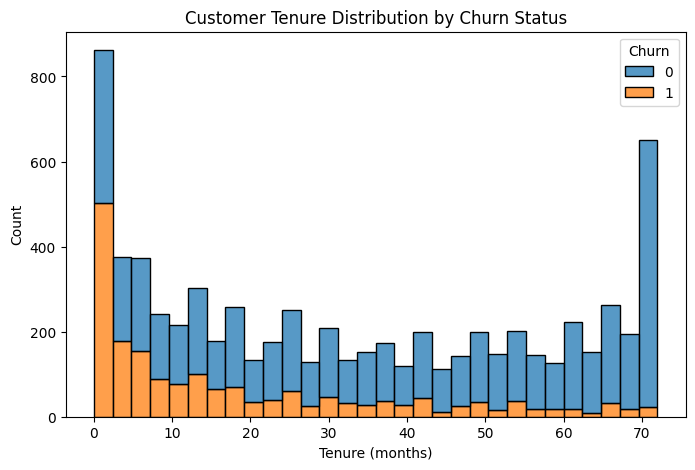

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Customer Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.show()

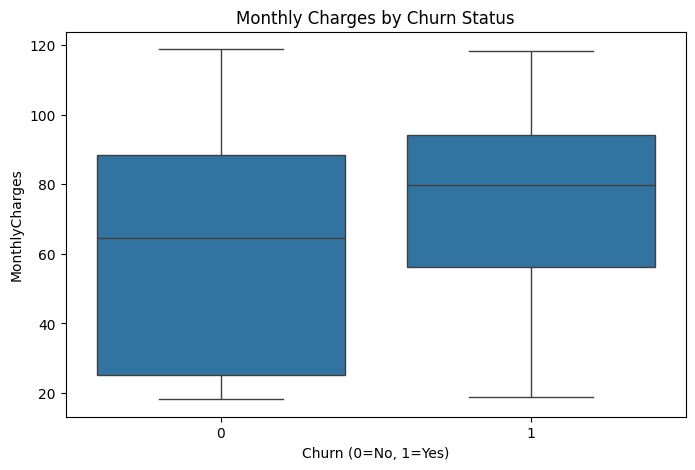

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.show()

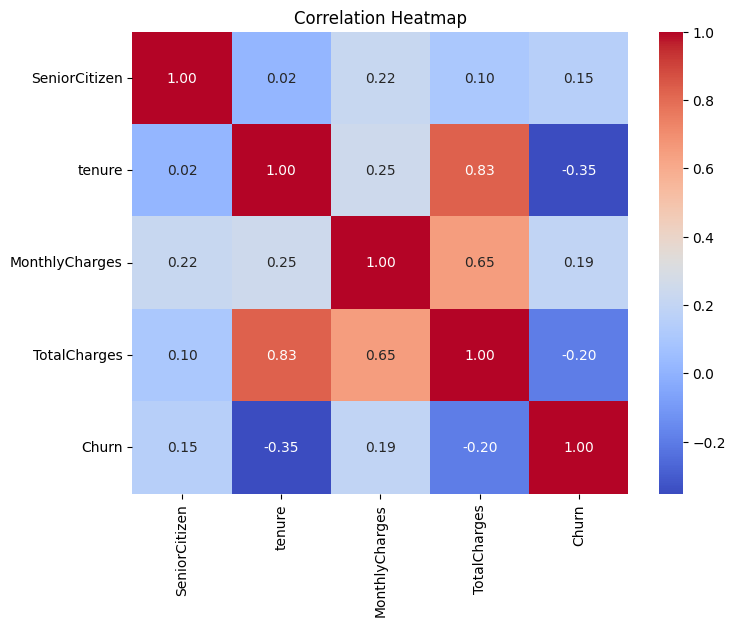

In [24]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [25]:
for col in ['TechSupport', 'OnlineSecurity', 'InternetService']:
    print(f"\n{col}:")
    print(df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100)


TechSupport:
TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn, dtype: float64

OnlineSecurity:
OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn, dtype: float64

InternetService:
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


In [26]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.shape)
df_encoded.head()

(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [27]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=3000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [32]:
log_preds = log_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, log_preds))

print("\nRandom Forest:")
print(classification_report(y_test, rf_preds))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [34]:
from sklearn.metrics import roc_auc_score

log_probs = log_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, log_probs):.3f}")
print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_probs):.3f}")

Logistic Regression ROC-AUC: 0.842
Random Forest ROC-AUC: 0.826


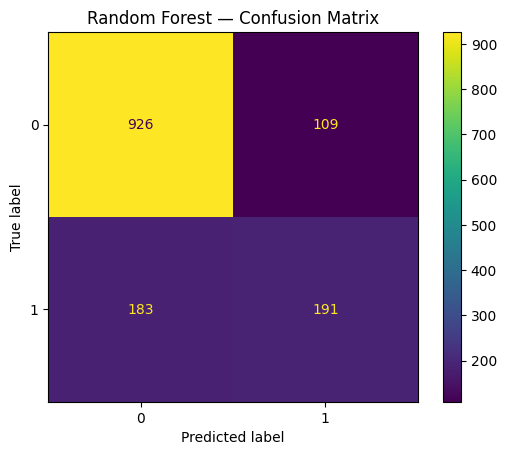

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf_preds)
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [36]:
import numpy as np

coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_model.coef_[0]
})
coefficients['abs_coef'] = coefficients['coefficient'].abs()
top_features = coefficients.sort_values('abs_coef', ascending=False).head(10)
print(top_features[['feature', 'coefficient']])

                           feature  coefficient
10     InternetService_Fiber optic     1.329782
25               Contract_Two year    -1.308958
24               Contract_One year    -0.679834
23             StreamingMovies_Yes     0.432772
21                 StreamingTV_Yes     0.432063
9                MultipleLines_Yes     0.394422
28  PaymentMethod_Electronic check     0.378196
26            PaperlessBilling_Yes     0.374072
13              OnlineSecurity_Yes    -0.320869
8   MultipleLines_No phone service     0.284850
